# TRAS - C60 Quenched

### Mounting the google drive

In [ ]:
# To begin, we import some libraries that we will need later.

# Some handy standard python libraries
import os

# The numpy library is very useful for many things
import numpy as np
import pandas as pd

# The pyplot module from matplotlib will allow us to plot things.
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from math import pi

In [ ]:
# Connect (mount) your google drive as a virtual directory accessible by this python code.
from google.colab import drive         # Import the python module that allows you to access your google drive
rootpathdrive = '/content/drive'       # This will be the directory as which your google drive will be known
drive.mount(rootpathdrive)             # Now connect to this google drive.

# At first use it will ask you to click on a link, after which you should give permission
# for outside processes to access your google drive. A authorization code is generated which should be entered
#(this is explained in https://colab.research.google.com/notebooks/io.ipynb#scrollTo=XDg9OBaYqRMd).

Mounted at /content/drive


In [ ]:
# # A good test to do is if you can see the contents of the directory in which you work on your google drive.
# # Here "My Drive" refers to the "root" of your google drive.
# # By default your notebook should be in a directory called Colab Notebooks.
# # This template assumes all files you want to read in are copied in the
# # same directory. Note the slash at the end of the first line.

# #==============================================================================================================
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/Crab_pulsar_template/' # Fin's Directory
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/CrabPulsar/Crab_pulsar_template' #Fin's 2
pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/TRAS/TRAS/Changing_Rep_Rate_C60' #Fin's New Groove
#pathTRAS = rootpathdrive+'/'+'My Drive/Colab Notebooks/TRAS/Changing_Rep_Rate_C60' #Sara's gaff
# #==============================================================================================================

filelist = []
for (dirpath, dirnames, filenames) in os.walk(pathTRAS):
    filelist.extend(filenames)
    break
print (filelist)   # Show the contents of your working directory. At least your notebook should show up here.


['100Hz BZbb025 2026-03-17 15-02-38 TA.csv', '100Hz BZbb025 2026-03-17 15-02-38 TA.xml', '200Hz BZbb025 2026-03-17 15-06-42 TA.csv', '200Hz BZbb025 2026-03-17 15-06-42 TA.xml', '400Hz BZbb025 2026-03-17 15-16-55 TA.csv', '400Hz BZbb025 2026-03-17 15-16-55 TA.xml', '500Hz BZbb025 2026-03-17 15-16-55 TA.csv', '500Hz BZbb025 2026-03-17 15-16-55 TA.xml', '800Hz BZbb025 2026-03-17 15-16-55 TA.xml', '800Hz BZbb025 2026-03-17 15-16-55 TA.csv', '1000Hz BZbb025 2026-03-17 15-16-55 TA.csv', '1000Hz BZbb025 2026-03-17 15-16-55 TA.xml', '2000Hz BZbb025 2026-03-17 15-16-55 TA.csv', '2000Hz BZbb025 2026-03-17 15-16-55 TA.xml', '4000Hz BZbb025 2026-03-17 15-16-55 TA.csv', '4000Hz BZbb025 2026-03-17 15-16-55 TA.xml', '5000Hz BZbb025 2026-03-17 15-16-55 TA.xml', '5000Hz BZbb025 2026-03-17 15-16-55 TA.csv', '10000Hz BZbb025 2026-03-17 15-16-55 TA.csv', '10000Hz BZbb025 2026-03-17 15-16-55 TA.xml', '20000Hz BZbb025 2026-03-17 15-16-55 TA.xml', '20000Hz BZbb025 2026-03-17 15-16-55 TA.csv', 'Changing_rep_r

## Loading and cleaning data
This step removes the negative bits before the exponential decay.

Processing: 100Hz BZbb025 2026-03-17 15-02-38 TA.csv → rep_rate = 100
  N_bg=39, mean=-0.08046, std=1.29503, stderr=0.12950
Processing: 200Hz BZbb025 2026-03-17 15-06-42 TA.csv → rep_rate = 200
  N_bg=39, mean=-0.28801, std=0.74040, stderr=0.05235
Processing: 400Hz BZbb025 2026-03-17 15-16-55 TA.csv → rep_rate = 400
  N_bg=39, mean=-0.42421, std=0.66110, stderr=0.03306
Processing: 500Hz BZbb025 2026-03-17 15-16-55 TA.csv → rep_rate = 500
  N_bg=39, mean=-0.25595, std=0.50873, stderr=0.02275
Processing: 800Hz BZbb025 2026-03-17 15-16-55 TA.csv → rep_rate = 800
  N_bg=39, mean=-0.41436, std=0.52947, stderr=0.01872
Processing: 1000Hz BZbb025 2026-03-17 15-16-55 TA.csv → rep_rate = 1000
  N_bg=39, mean=-0.50609, std=0.29146, stderr=0.00922
Processing: 2000Hz BZbb025 2026-03-17 15-16-55 TA.csv → rep_rate = 2000
  N_bg=39, mean=-0.67698, std=0.49302, stderr=0.01102
Processing: 4000Hz BZbb025 2026-03-17 15-16-55 TA.csv → rep_rate = 4000
  N_bg=39, mean=-0.72738, std=0.11672, stderr=0.00185
Pr

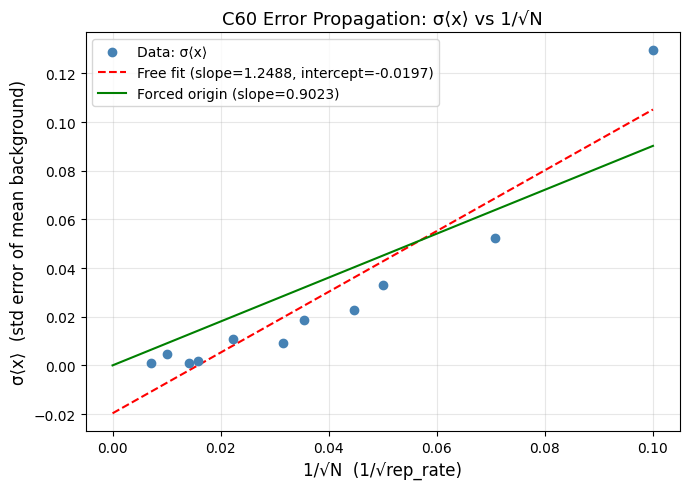


Free fit slope:           1.24877  ← estimate of σ_x
Free fit intercept:       -0.01970  ← should be ~0
Forced-origin fit slope:  0.90234  ← best estimate of σ_x


In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

signal_std = []
signal_stderr = []
rep_rates = []
signal_mean_array = []

for file in filelist:
    if file.endswith(".csv") and "TA" in file:

        csv_title = file

        # ✅ FIXED: extract "100Hz", "200Hz", etc.
        match = re.search(r'(\d+)\s*Hz', csv_title, re.IGNORECASE)
        if match:
            rep_rate = int(match.group(1))
        else:
            print(f"Skipping file (no rep rate found): {csv_title}")
            continue

        print(f"Processing: {csv_title} → rep_rate = {rep_rate}")

        # --- Load data ---
        df = pd.read_csv(
            os.path.join(pathTRAS, csv_title),
            sep=";",
            header=None,
            names=["time", "signal"]
        )

        df = df.iloc[1:].reset_index(drop=True)

        # Safer conversion
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.dropna()

        # --- Background selection ---
        df_bg = df[df["time"] < -10].reset_index(drop=True)
        signal = df_bg["signal"].to_numpy()

        if len(signal) < 2:
            print(f"Skipping (not enough background points): {csv_title}")
            continue

        # ⚠️ Important assumption:
        # You're assuming rep_rate = number of averages (N)
        # This is only true if your system averages over 1 second
        N = rep_rate

        # --- Statistics ---
        signal_mean = np.mean(signal)
        std = np.std(signal, ddof=1)
        stderr = std / np.sqrt(N)

        print(f"  N_bg={len(signal)}, mean={signal_mean:.5f}, std={std:.5f}, stderr={stderr:.5f}")

        rep_rates.append(rep_rate)
        signal_mean_array.append(signal_mean)
        signal_std.append(std)
        signal_stderr.append(stderr)

# --- Convert to arrays ---
rep_rates = np.array(rep_rates)
signal_mean_array = np.array(signal_mean_array)
signal_std = np.array(signal_std)
signal_stderr = np.array(signal_stderr)

# --- Sort ---
sorted_idx = np.argsort(rep_rates)
rep_rates         = rep_rates[sorted_idx]
signal_mean_array = signal_mean_array[sorted_idx]
signal_std        = signal_std[sorted_idx]
signal_stderr     = signal_stderr[sorted_idx]

# --- Transform ---
inv_sqrt_N = 1 / np.sqrt(rep_rates)

# --- Filter invalid values ---
valid = np.isfinite(inv_sqrt_N) & np.isfinite(signal_stderr)
print(f"\nValid points for fitting: {valid.sum()} / {len(valid)}")

inv_sqrt_N_fit    = inv_sqrt_N[valid]
signal_stderr_fit = signal_stderr[valid]

# --- Fits ---
# Forced through origin
slope_forced = np.linalg.lstsq(
    inv_sqrt_N_fit[:, np.newaxis],
    signal_stderr_fit,
    rcond=None
)[0][0]

# Free intercept
coeffs = np.polyfit(inv_sqrt_N_fit, signal_stderr_fit, 1)

# --- Fit line ---
x_fit = np.linspace(0, max(inv_sqrt_N_fit), 100)

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(inv_sqrt_N, signal_stderr,
           color='steelblue', zorder=5, label='Data: σ⟨x⟩')

ax.plot(x_fit, coeffs[0]*x_fit + coeffs[1], 'r--',
        label=f'Free fit (slope={coeffs[0]:.4f}, intercept={coeffs[1]:.4f})')

ax.plot(x_fit, slope_forced * x_fit, 'g-',
        label=f'Forced origin (slope={slope_forced:.4f})')

ax.set_xlabel('1/√N  (1/√rep_rate)', fontsize=12)
ax.set_ylabel('σ⟨x⟩  (std error of mean background)', fontsize=12)
ax.set_title('C60 Error Propagation: σ⟨x⟩ vs 1/√N', fontsize=13)

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    os.path.join(pathTRAS, "Changing_rep_rate_C60.png"),
    dpi=300, bbox_inches="tight"
)

plt.show()

# --- Results ---
print(f"\nFree fit slope:           {coeffs[0]:.5f}  ← estimate of σ_x")
print(f"Free fit intercept:       {coeffs[1]:.5f}  ← should be ~0")
print(f"Forced-origin fit slope:  {slope_forced:.5f}  ← best estimate of σ_x")

Index value = -0.41397524875044156 Uncert = 0.11617352751329706


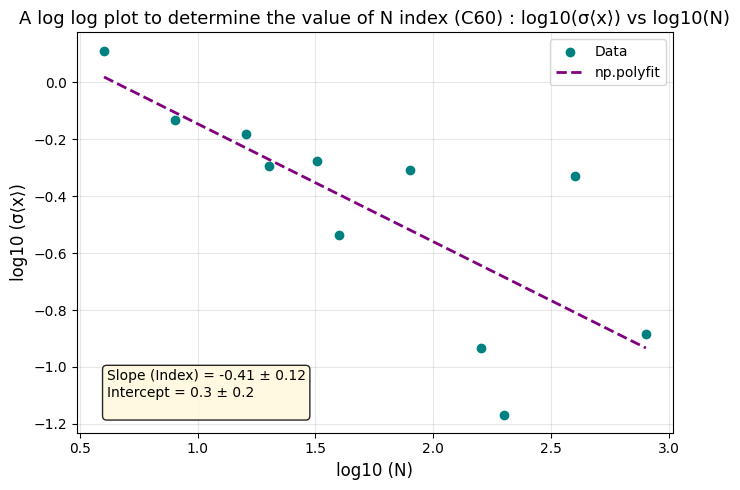

In [ ]:
from IPython.core.display import json
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
t_acq = 20000/500000

signal_std = []    # σ_x (std of individual background points)
signal_noise = [] # σ<x> (Average error## =          std/sqrt(N))
signal_noise_err = []
rep_rates = []
signal_mean_array = []

for file in filelist:
    if file.endswith(".csv") and "TA" in file:

        csv_title = file

        # --- Robust rep rate extraction ---
        match = re.search(r'(\d+)\s*Hz', csv_title, re.IGNORECASE)
        if match:
            rep_rate = int(match.group(1))
        else:
            #print(f"Skipping file (no rep rate found): {csv_title}")
            continue

        #print(f"Processing: {csv_title} → rep_rate = {rep_rate}")

        # --- Load data ---
        df = pd.read_csv(
            os.path.join(pathTRAS, csv_title),
            sep=";",
            header=None,
            names=["time", "signal"]
        )

        df = df.iloc[1:].reset_index(drop=True)
        df = df.astype(float)

        # --- Background selection ---
        df_bg = df[df["time"] < -10].reset_index(drop=True)
        signal = df_bg["signal"].to_numpy()

        if len(signal) < 2:
            print(f"Skipping (not enough background points): {csv_title}")
            continue

        N = rep_rate * (t_acq) # assuming rep_rate = number of averages per point

        # --- Statistics ---
        signal_mean = np.mean(signal)
        std = np.std(signal, ddof=1)   # this is σ⟨x⟩

        N_bg = len(signal)

        std_err = std / np.sqrt(2 * (N_bg - 1))

        #print(f"  N_bg={len(signal)}, mean={signal_mean:.5f}, noise={std:.5f}")

        rep_rates.append(rep_rate)
        signal_mean_array.append(signal_mean)
        signal_noise.append(std)
        signal_noise_err.append(std_err)

# --- Convert to arrays ---
rep_rates = np.array(rep_rates)
signal_mean_array = np.array(signal_mean_array)
signal_noise = np.array(signal_noise)
signal_noise_err = np.array(signal_noise_err)

# --- Sort by rep rate ---
sorted_idx = np.argsort(rep_rates)
rep_rates         = rep_rates[sorted_idx]
signal_mean_array = signal_mean_array[sorted_idx]
signal_noise = signal_noise[sorted_idx]
signal_noise_err = signal_noise_err[sorted_idx]

# --- Finley Corner ---

y = np.log10(signal_noise)
#y_err = signal_noise_err / (signal_noise * np.log(10))
x = np.log10(rep_rates*t_acq)
#plt.scatter(x,y)
#plt.show()

# model: INVALID
# model = N ** (-0.5)

# A = np.sum(y * model / y_err**2) / np.sum(model**2 / y_err**2)

# y_fit = A * model
# chi2 = np.sum(((y - y_fit) / y_err) ** 2)

# dof = len(y) - 1   # one fitted parameter (A)
# chi2_red = chi2 / dof

# print(chi2_red)

###

coeffs, cov = np.polyfit(x, y, 1, cov = True)

slope = coeffs[0]
intercept = coeffs[1]

slope_err = np.sqrt(cov[0, 0])
intercept_err = np.sqrt(cov[1, 1])



x_fit = np.linspace(min(x), max(x), 100)

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(x, y,
           color='teal', zorder=5, label='Data')

ax.plot(x_fit, coeffs[0]*x_fit + coeffs[1], color='purple', linestyle='dashed', linewidth=2, markersize=7, label=f'np.polyfit')

#ax.plot(x_fit, slope_forced * x_fit, 'g-',
 #       label=f'Forced origin (slope={slope_forced:.4f})')

#ax.errorbar(x, y, yerr=y_err,
 #           fmt='o', color='steelblue',
  #          capsize=4, label='Data with uncertainty')
# Errors Not Valid

ax.set_xlabel('log10 (N)', fontsize=12)
ax.set_ylabel('log10 (σ⟨x⟩)', fontsize=12)
ax.set_title('A log log plot to determine the value of N index (C60) : log10(σ⟨x⟩) vs log10(N)', fontsize=13)

ax.legend()
ax.grid(True, alpha=0.3)

ax.text(0.05, 0.1,
        f"Slope (Index) = {slope:.2f} ± {slope_err:.2f}\n"
        f"Intercept = {intercept:.1f} ± {intercept_err:.1f}\n",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='center',
        bbox=dict(boxstyle="round", facecolor="cornsilk", alpha=0.85))

plt.tight_layout()
plt.savefig(os.path.join(pathTRAS, "Graph_Rep_Rate_C60.png"),
    dpi=300, bbox_inches="tight")
print('Index value =',slope,'Uncert =',slope_err)
